In [4]:
# tf_flowers dataset(5종 꽃이미지)으로 전이학습 + 미세조정

import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers, models

(train_ds, val_ds), metadata = tfds.load(
    'tf_flowers',
    split=['train[:80%]', 'train[80%:]'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True
)

ds_info = metadata

for image, label in train_ds.take(1):
    print(type(image), type(label))

print(ds_info.features['label'].names)

2026-05-15 11:54:51.149182: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-15 11:54:51.171254: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-15 11:54:51.171302: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-15 11:54:51.184415: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-15 11:54:52.106992: W tensorflow/compiler/tf

<class 'tensorflow.python.framework.ops.EagerTensor'> <class 'tensorflow.python.framework.ops.EagerTensor'>
['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']


2026-05-15 11:54:54.323734: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-05-15 11:54:54.358764: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-05-15 11:54:54.359010: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [5]:
# 전처리
IMG_SIZE = (160, 160)
BATCH_SIZE = 32

def preprocessFunc(image, label):
  image = tf.image.resize(image, IMG_SIZE) # Corrected from tf.image_resize
  image = tf.cast(image, tf.float32) /255.0
  return image, label

train_ds = train_ds.map(preprocessFunc).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(preprocessFunc).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# 백본(base model) 불러오기
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
  	include_top=False,
  	weights='imagenet'
)

base_model.trainable = False
model = tf.keras.Sequential([
    base_model, # 학습에 참여없이 특징추출기(Conv+Pool)의 역할만 함
    layers.GlobalAveragePooling2D(),
    layers.Dense(units=128, activation='relu'),
    layers.Dense(units=ds_info.features['label'].num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

None


In [6]:
model.fit(train_ds, validation_data=val_ds, epochs=5)

loss, acc = model.evaluate(val_ds)
print(f'loss: {loss}, acc: {acc}')
print(f'loss:{loss:.4f}, acc:{acc:.4f}')

Epoch 1/5


I0000 00:00:1778813708.385474  172314 service.cc:145] XLA service 0x7dc2c4010ec0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778813708.385533  172314 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce MX250, Compute Capability 6.1
2026-05-15 11:55:08.533430: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-05-15 11:55:09.288306: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907


 3/92 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.2587 - loss: 1.8790 

I0000 00:00:1778813718.096569  172314 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


92/92 ━━━━━━━━━━━━━━━━━━━━ 43s 319ms/step - accuracy: 0.7871 - loss: 0.5701 - val_accuracy: 0.8815 - val_loss: 0.3282
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - accuracy: 0.9152 - loss: 0.2361 - val_accuracy: 0.8856 - val_loss: 0.3165
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - accuracy: 0.9653 - loss: 0.1340 - val_accuracy: 0.8869 - val_loss: 0.3271
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - accuracy: 0.9823 - loss: 0.0810 - val_accuracy: 0.8815 - val_loss: 0.3781
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - accuracy: 0.9918 - loss: 0.0506 - val_accuracy: 0.8869 - val_loss: 0.3620
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.8869 - loss: 0.3620
loss: 0.362002432346344, acc: 0.8869209885597229
loss:0.3620, acc:0.8869


In [7]:
# 다음 단계 - Fine tunning (base model의 일부 레이어만 학습에 참여)
base_model.trainable = True

fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
  layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print('미세 조정 시작 .....')
model.fit(train_ds, validation_data=val_ds, epochs=5)

loss, acc = model.evaluate(val_ds)
print(f'fine tunning : loss:{loss:.4f}, acc:{acc:.4f}')

미세 조정 시작 .....
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 65s 426ms/step - accuracy: 0.7769 - loss: 0.6379 - val_accuracy: 0.8896 - val_loss: 0.3612
Epoch 2/5
 1/92 ━━━━━━━━━━━━━━━━━━━━ 21s 234ms/step - accuracy: 0.7812 - loss: 0.5439

2026-05-15 11:57:30.710980: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 16777472 bytes after encountering the first element of size 16777472 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 133ms/step - accuracy: 0.8106 - loss: 0.5587 - val_accuracy: 0.8869 - val_loss: 0.3635
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 135ms/step - accuracy: 0.8294 - loss: 0.4778 - val_accuracy: 0.8801 - val_loss: 0.3674
Epoch 4/5
 1/92 ━━━━━━━━━━━━━━━━━━━━ 19s 209ms/step - accuracy: 0.8125 - loss: 0.4824

2026-05-15 11:57:55.575823: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 16777472 bytes after encountering the first element of size 16777472 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 136ms/step - accuracy: 0.8498 - loss: 0.4333 - val_accuracy: 0.8747 - val_loss: 0.3716
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 136ms/step - accuracy: 0.8696 - loss: 0.3885 - val_accuracy: 0.8747 - val_loss: 0.3752
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.8747 - loss: 0.3752
fine tunning : loss:0.3752, acc:0.8747


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


2026-05-15 12:05:00.536738: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


[[4.74798611e-07 1.79090262e-06 2.28728153e-04 3.58731231e-05
  9.99733150e-01]
 [6.60707773e-12 1.73474546e-09 9.99960065e-01 1.87584920e-10
  3.99408600e-05]
 [5.25899195e-05 6.57712872e-06 7.91443288e-01 6.76773302e-03
  2.01729804e-01]
 [5.76919099e-08 5.39827703e-08 9.98432577e-01 5.52020254e-07
  1.56667735e-03]
 [1.44137237e-02 9.85497296e-01 2.88022170e-06 8.51295263e-05
  9.46144894e-07]
 [8.10030922e-02 1.77097350e-01 8.62756977e-04 1.21616555e-04
  7.40915239e-01]
 [5.83506981e-03 9.88946855e-01 4.01943224e-03 7.05450831e-04
  4.93232801e-04]
 [7.83757781e-10 1.31871536e-09 9.98366535e-01 4.86683870e-12
  1.63345912e-03]
 [7.08429841e-04 6.48917339e-04 7.01451907e-03 9.88342106e-01
  3.28601710e-03]
 [4.28931202e-08 7.58502608e-07 1.13288502e-06 9.99987960e-01
  1.00918360e-05]
 [1.45477103e-03 2.15361267e-03 1.64622173e-03 5.92271751e-03
  9.88822699e-01]
 [2.32868129e-03 6.73888018e-04 5.66902123e-02 9.36499357e-01
  3.80774704e-03]
 [6.97291835e-05 2.01345067e-02 8.399539

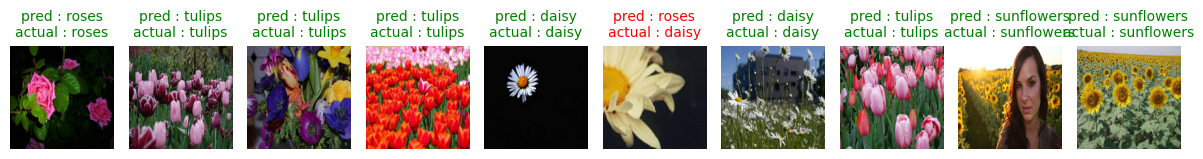

In [12]:
# 검증 데이터셋 에서 이미지 1개 추출
for image, label in val_ds.take(1):
  sample_image = image
  sample_label = label

pred_probs = model.predict(sample_image)
print(pred_probs)

pred_classes = tf.argmax(pred_probs, axis=-1)
print(pred_classes)

# 클래스 이름 얻기
class_names = ds_info.features['label'].names
print(class_names)
# 예측값과 실제값 출력
for i in range(len(sample_image)):
  predict_index = int(pred_classes[i])
  actual_index = int(sample_label[i])

  predict_name = class_names[predict_index]
  actual_name = class_names[actual_index]

# 시각화
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
for i in range(10):
  plt.subplot(1, 10, i + 1)
  plt.imshow(sample_image[i])

  predicted_label = class_names[pred_classes[i]]
  actual_label = class_names[sample_label[i]]
  
  color = "green" if predicted_label == actual_label else "red"
  plt.title(f"pred : {predicted_label}\nactual : {actual_label}", color = color, fontsize=10)
  plt.axis("off")
plt.tight_layout()
plt.show()
